# Lesson 5.2 — Boundary vs Internal Singularities, Joint-Rate Blow-Up
**Module 6 · Unit 5 · Lesson 18**

Near a singularity, commanding the **lost** direction makes joint rates explode like 1/σ_min. The planar 2R boundary singularity sits at the workspace edge (reach = L₁+L₂).

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
def reach(P,T,q):
    M=forward_chain(P,T,q)[-1]; return float(np.hypot(M[0,3],M[1,3]))
P2=[(0,0,1.0,0),(0,0,1.0,0)]; T2=["R","R"]            # planar 2R, L1=L2=1


## Joint-rate blow-up: command the lost direction, ‖q̇‖ tracks 1/σ_min

theta2= 0.60  sigma_min=0.2638  ||qdot||=   3.79  1/sigma_min=   3.79
theta2= 0.40  sigma_min=0.1775  ||qdot||=   5.63  1/sigma_min=   5.63
theta2= 0.20  sigma_min=0.0893  ||qdot||=  11.20  1/sigma_min=  11.20
theta2= 0.10  sigma_min=0.0447  ||qdot||=  22.37  1/sigma_min=  22.37
theta2= 0.05  sigma_min=0.0224  ||qdot||=  44.73  1/sigma_min=  44.73
theta2= 0.02  sigma_min=0.0089  ||qdot||= 111.81  1/sigma_min= 111.81


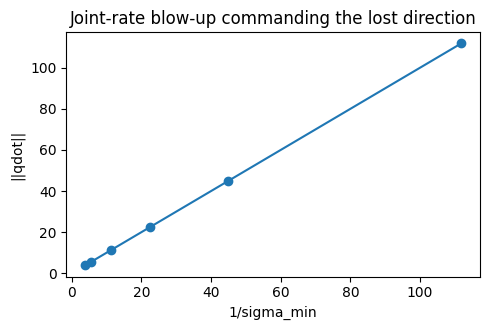

In [2]:
checks=[]
import matplotlib.pyplot as plt
t2s=np.array([0.6,0.4,0.2,0.1,0.05,0.02])
smin=[]; qn=[]
for t2 in t2s:
    J=Jv_planar(P2,T2,np.array([0.4,t2])); U,S,Vt=np.linalg.svd(J)
    xi=U[:,1]                       # unit command along the lost (smallest-sigma) direction
    qd=np.linalg.solve(J,xi)
    smin.append(S[1]); qn.append(np.linalg.norm(qd))
    print(f"theta2={t2:5.2f}  sigma_min={S[1]:.4f}  ||qdot||={np.linalg.norm(qd):7.2f}  1/sigma_min={1/S[1]:7.2f}")
checks.append(np.allclose(qn,1/np.array(smin),rtol=1e-6))
plt.figure(figsize=(5,3.4)); plt.plot(1/np.array(smin),qn,'o-'); plt.xlabel('1/sigma_min'); plt.ylabel('||qdot||')
plt.title('Joint-rate blow-up commanding the lost direction'); plt.tight_layout(); plt.show()

## A command along the *remaining* direction stays cheap

In [3]:
J=Jv_planar(P2,T2,np.array([0.4,0.05])); U,S,Vt=np.linalg.svd(J)
qd_lost=np.linalg.solve(J,U[:,1]); qd_keep=np.linalg.solve(J,U[:,0])
print("near-singular ||qdot|| lost dir:",round(np.linalg.norm(qd_lost),2)," remaining dir:",round(np.linalg.norm(qd_keep),3))
checks.append(np.linalg.norm(qd_keep) < 0.1*np.linalg.norm(qd_lost))

near-singular ||qdot|| lost dir: 44.73  remaining dir: 0.447


## Boundary singularity = workspace edge (reach = L₁+L₂)

In [4]:
print("reach at straight (theta2=0):",round(reach(P2,T2,np.array([0.4,0.0])),3),"= L1+L2 = 2.0")
print("reach at folded (theta2=pi):",round(reach(P2,T2,np.array([0.4,np.pi])),3),"= |L1-L2| = 0.0")
checks.append(np.isclose(reach(P2,T2,np.array([0.4,0.0])),2.0) and np.isclose(reach(P2,T2,np.array([0.4,np.pi])),0.0,atol=1e-6))
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

reach at straight (theta2=0): 2.0 = L1+L2 = 2.0
reach at folded (theta2=pi): 0.0 = |L1-L2| = 0.0
All checks passed.
